# 3.6.2 Cazzaro and Pisinger 2022 Fig. 6

This is used in the paper **Flexible cable routing framework for wind farm collection system optimization**.

In [1]:
import pickle
from importlib.resources import files
from matplotlib import pyplot as plt

In [2]:
from optiwindnet.interarraylib import G_from_S
from optiwindnet.svg import svgplot
from optiwindnet.plotting import pplot
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.importer import L_from_yaml
from optiwindnet.pathfinding import PathFinder
from optiwindnet.MILP import solver_factory, ModelOptions

In [3]:
%config InlineBackend.figure_formats = ['svg']
plt.rcParams['svg.fonttype'] = 'none'

## Reference solution

Cazzaro, D., & Pisinger, D. (2022). Balanced cable routing for offshore wind farms with obstacles. Networks, 80(4), 386–406. https://doi.org/10.1002/net.22100

In [4]:
G_ref = pickle.load(open('data/cazzaro_2022_paper_routeset.pkl', 'rb'))

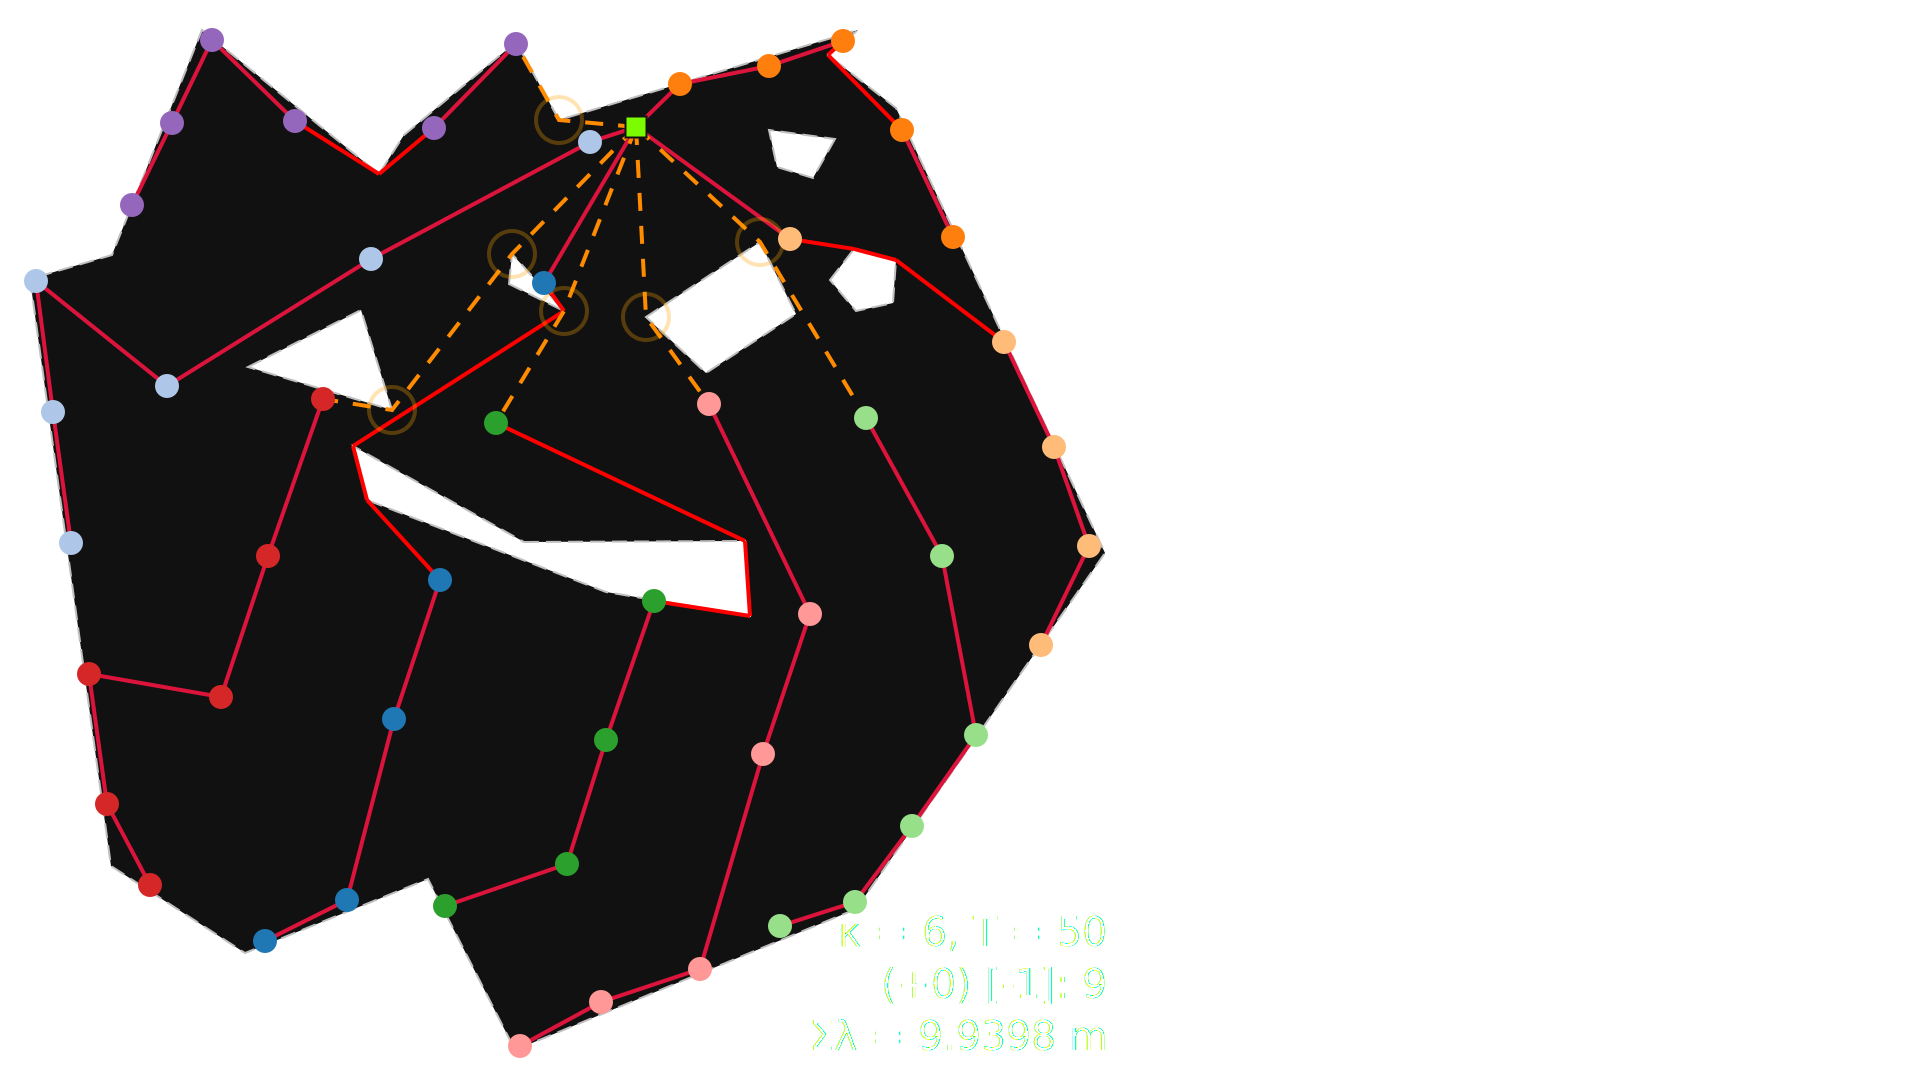

In [5]:
svgplot(G_ref)

## Start here

In [6]:
solver = solver_factory('gurobi')

In [7]:
L = L_from_yaml(files('optiwindnet.data') / 'Cazzaro-2022.yaml')

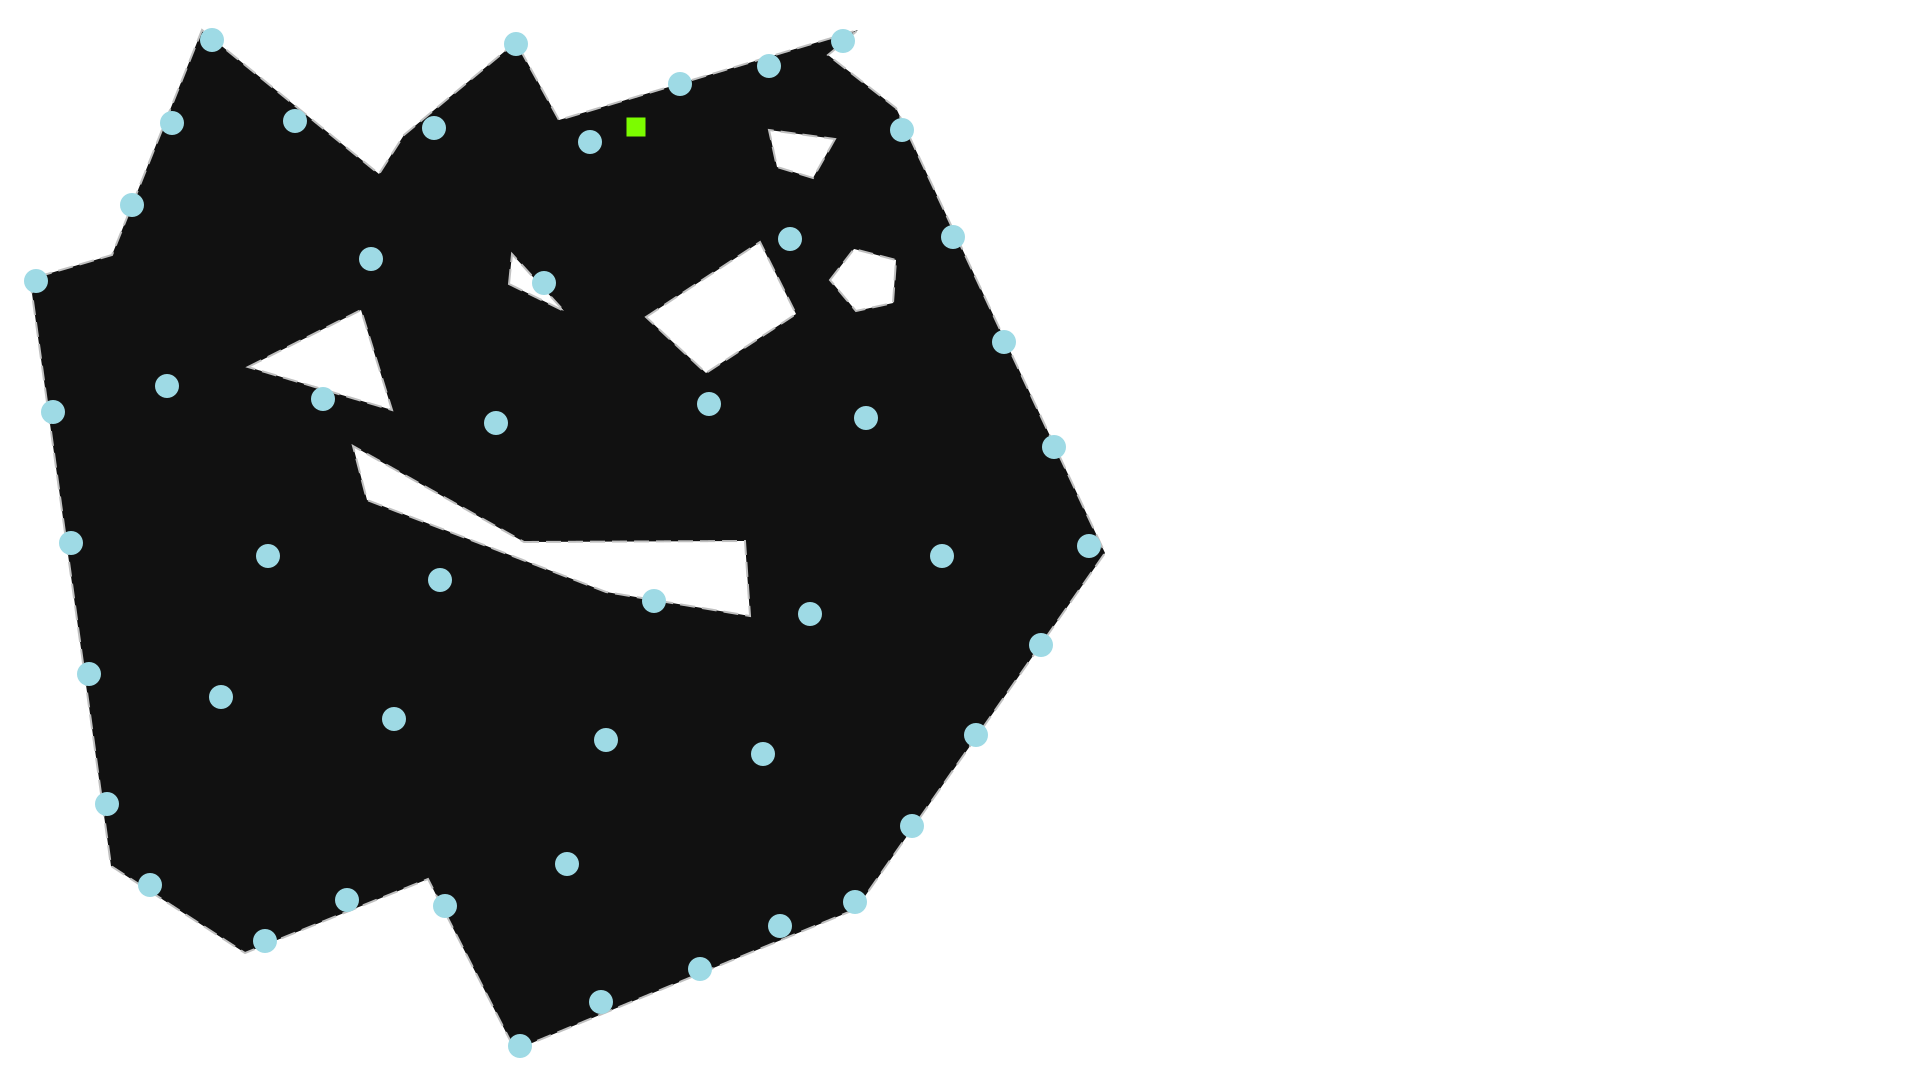

In [8]:
svgplot(L)

In [9]:
P, A = make_planar_embedding(L)

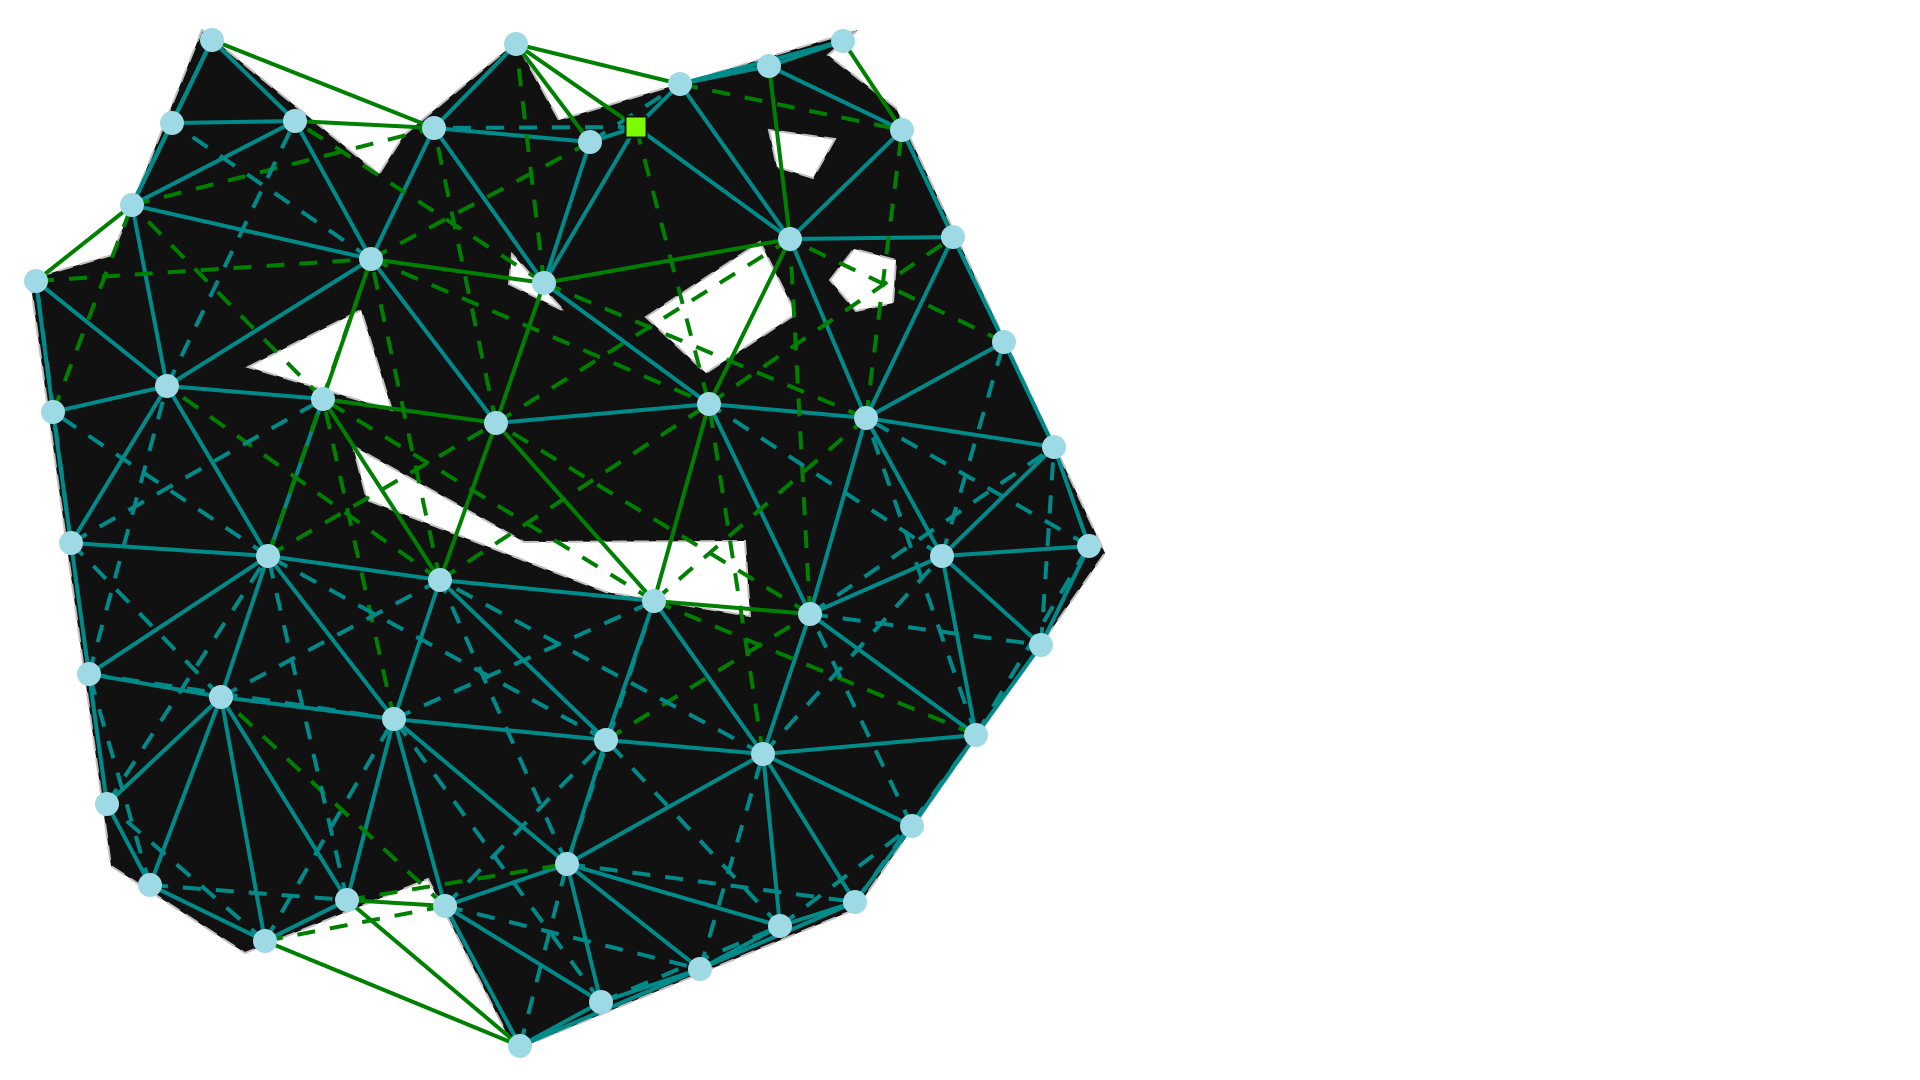

In [10]:
svgplot(A)

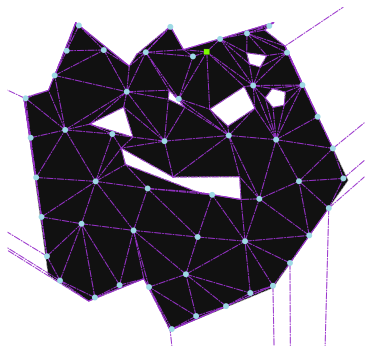

In [11]:
pplot(P, A);

## Pre-solve

In [12]:
Sʹ = hgs_cvrp(A, capacity=6, time_limit=0.5, balanced=True)
Sʹ.graph['solution_time']

(0.18,)

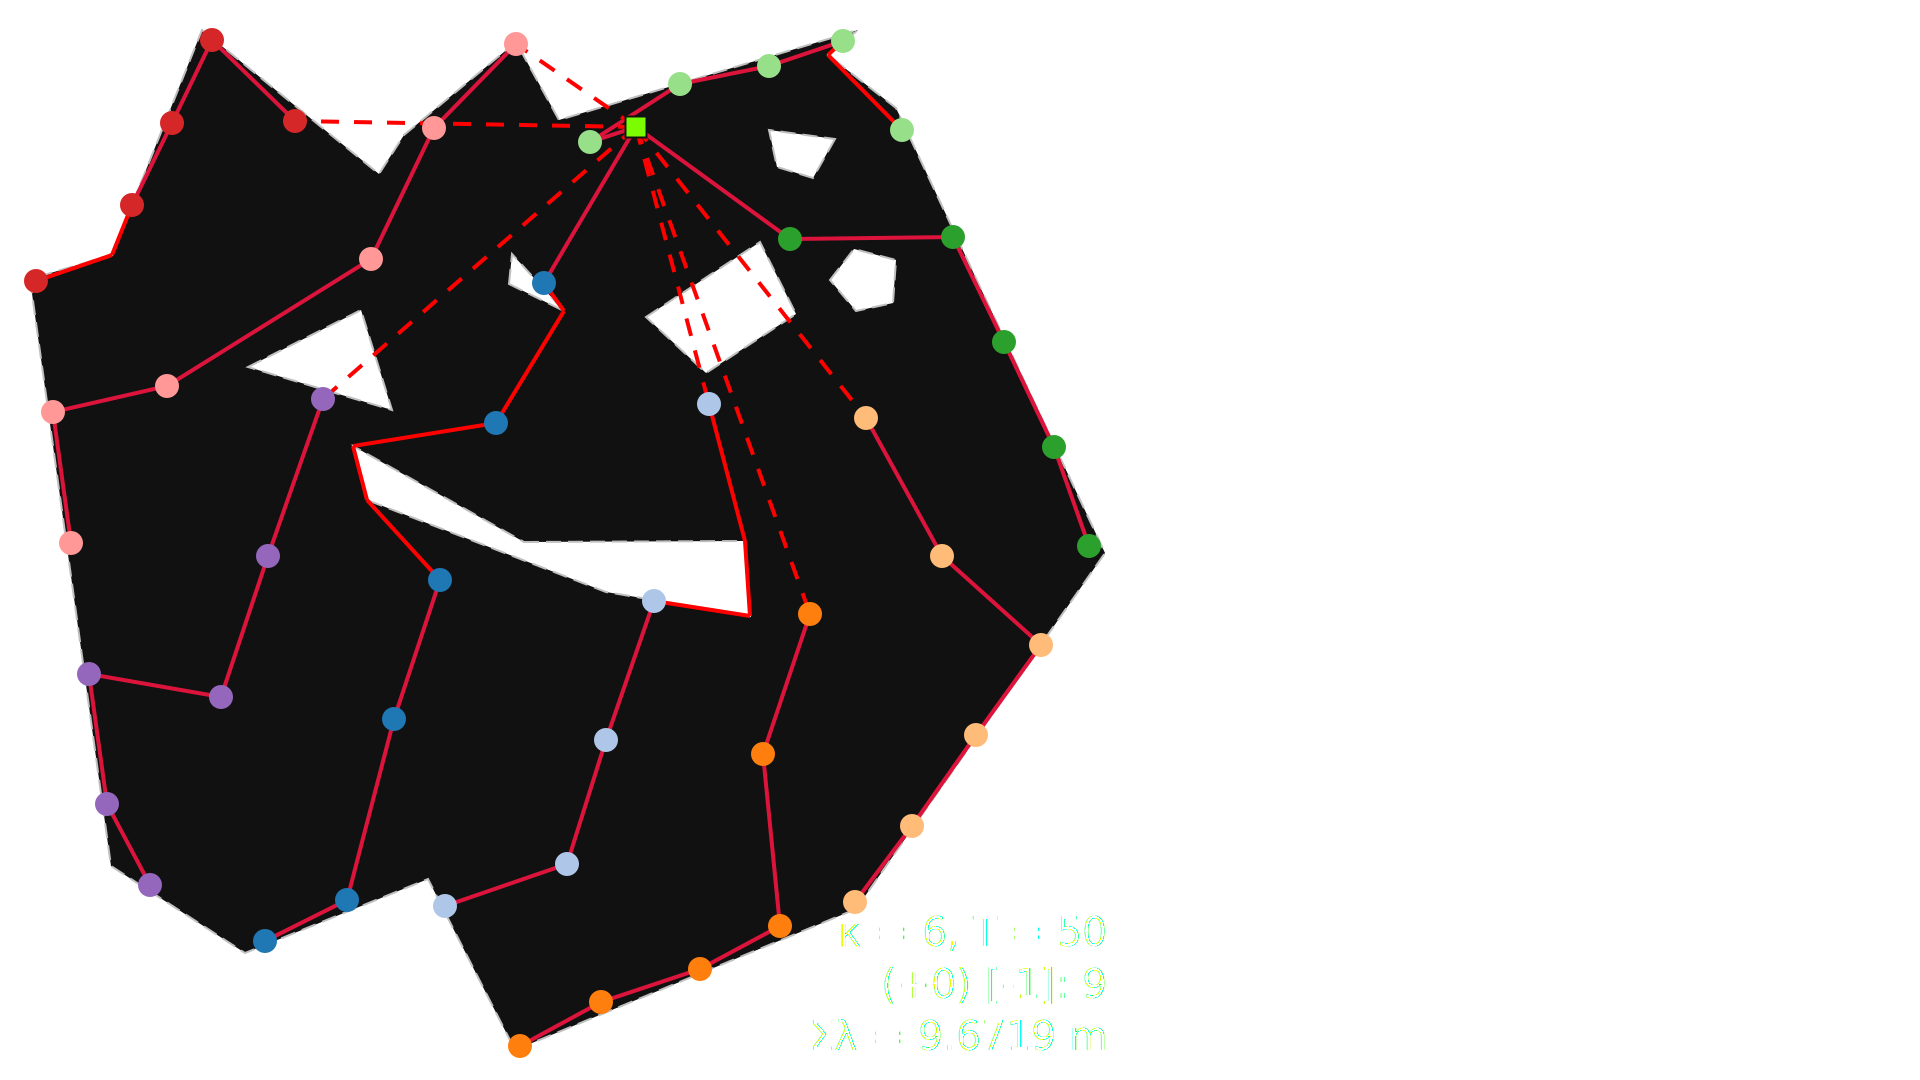

In [13]:
Gʹ = G_from_S(Sʹ, A)
svgplot(Gʹ)

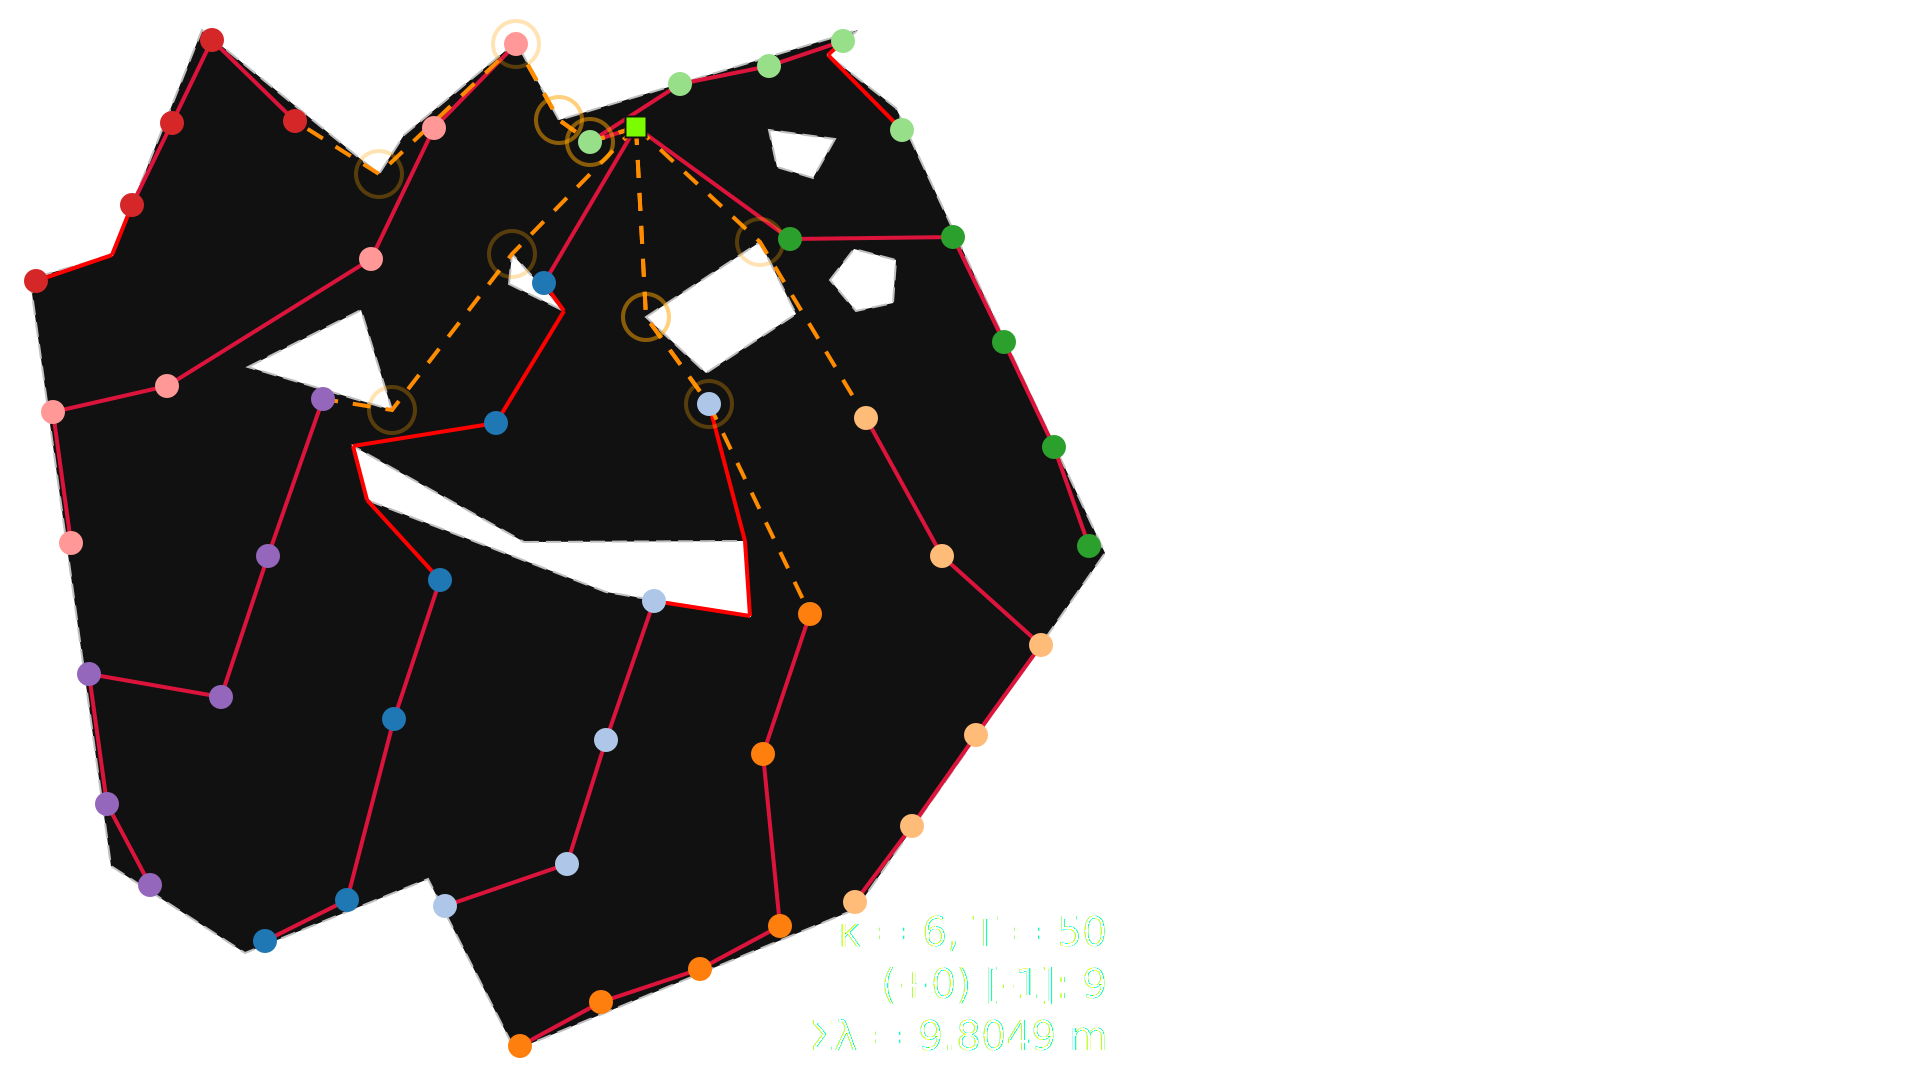

In [14]:
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [15]:
1 - Hʹ.size(weight='length')/G_ref.size(weight='length')

0.013578500078660682

In [16]:
solver.set_problem(
    P, A,
    capacity=6,
    model_options=ModelOptions(
        topology="radial",
        feeder_route="segmented",
        feeder_limit="minimum",
        balanced=True,
    ),
    warmstart=Sʹ,
)

In [17]:
solver.solve(
    mip_gap=0.005,
    time_limit=35,
    verbose=True,
    options=dict(
        mipfocus=2,
        poolgap=0.015,
        poolsearchmode=2,
        poolsolutions=20
    ),
)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  35
MIPGap  0.005
MIPFocus  2
PoolSolutions  20
PoolSearchMode  2
PoolGap  0.015

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 1442 rows, 872 columns and 5342 nonzeros (Min)
Model fingerprint: 0x43b98d1c
Model has 436 linear objective coefficients
Variable types: 0 continuous, 872 integer (436 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [6e-02, 1e+00]
  Bounds range     [1e+00, 6e+00]
  RHS range        [1e+00, 5e+01]

Loaded user MIP start with objective 9.67192

Presolve removed 192 rows and 0 columns
Presolve time: 0.01s
Presolved: 1250 rows, 872 columns, 4908 nonzeros
Variable types: 0 

SolutionInfo(runtime=22.922324180603027, bound=9.671920168635916, objective=9.671920168635916, relgap=0.0, termination='optimal')

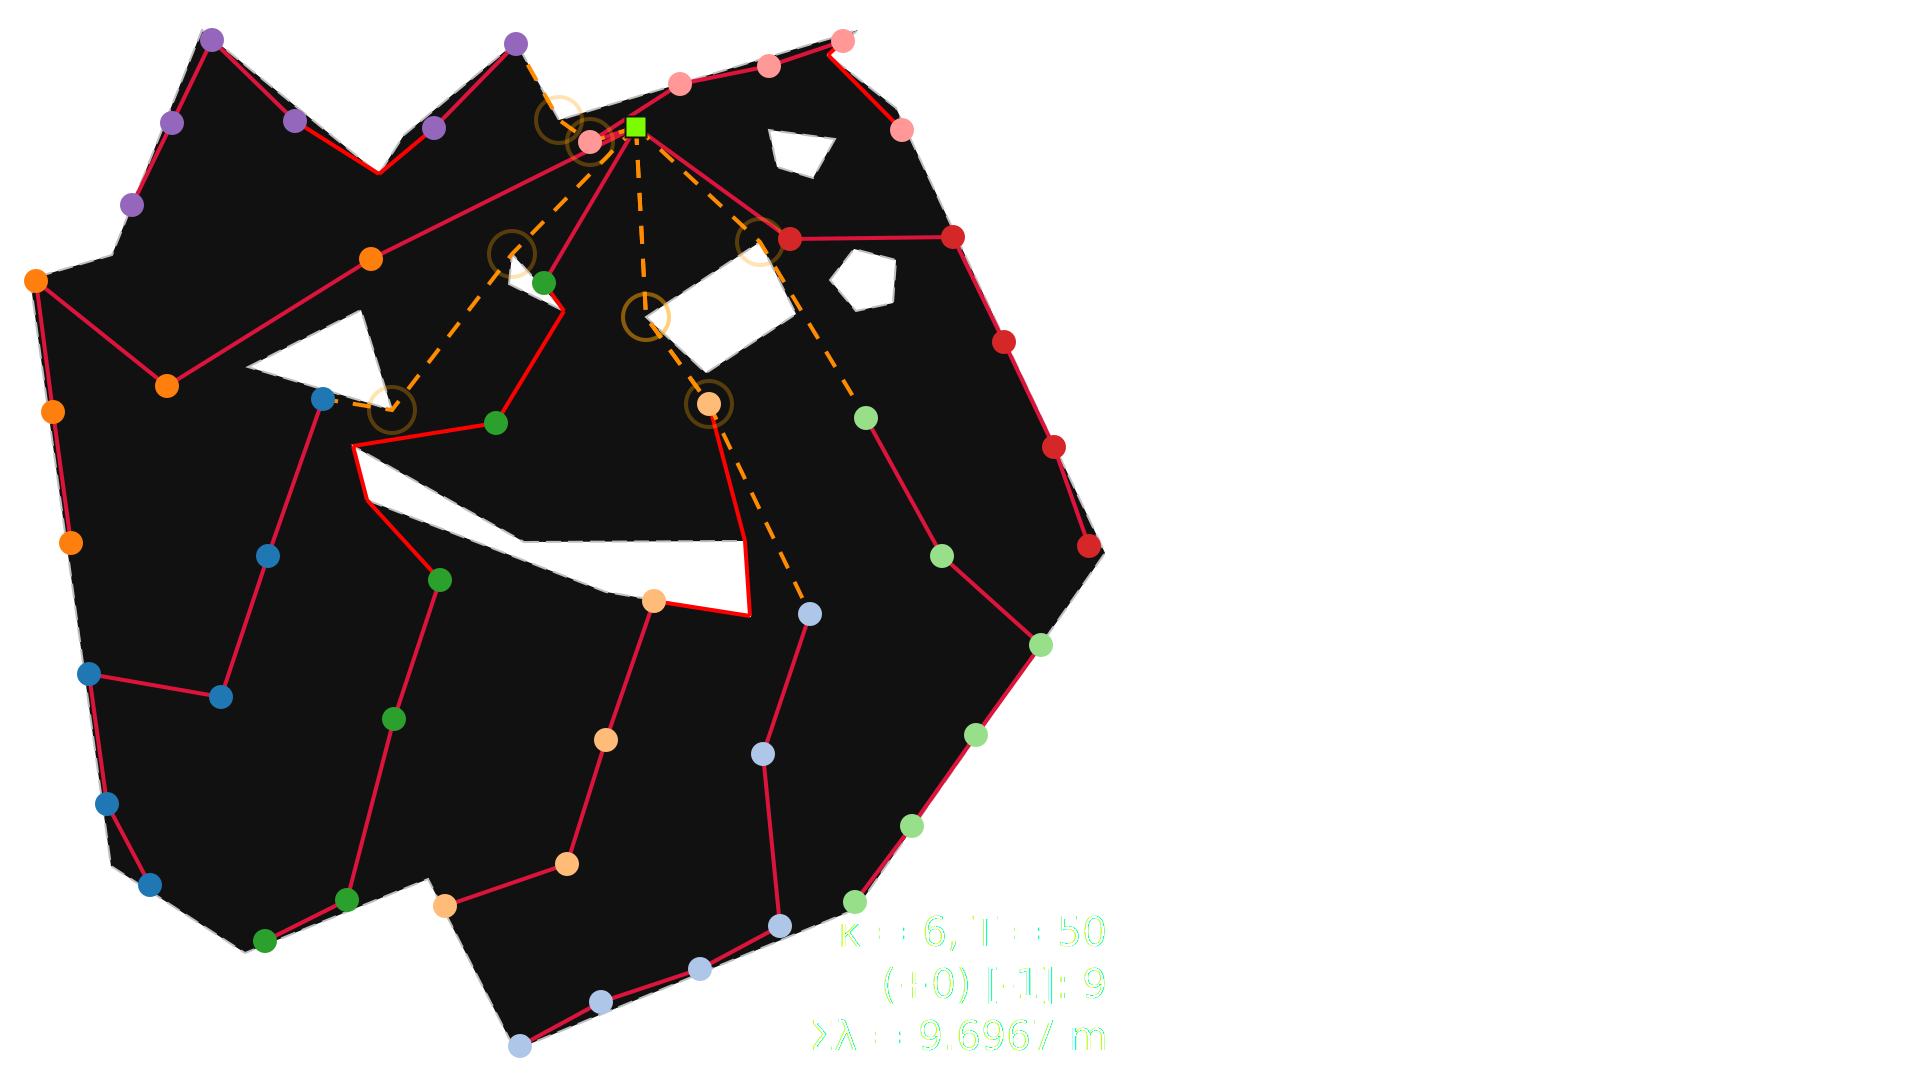

In [18]:
S, G = solver.get_solution()
svgplot(G)

In [19]:
1 - G.size(weight='length')/G_ref.size(weight='length')

0.024457285866890444

In [20]:
with open('cazzaro_2022_comparison_κ_6_radial_balanced.pkl', 'wb') as outfile:
    pickle.dump(G, outfile)